# Descrição do Dataset

**Título**:  
Série Histórica de Preços de Combustíveis - 1° Semestre de 2025<br>
https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis<br>
**Órgão responsável pela publicação**:  
Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP)<br>
**Descrição**:  
Série Histórica de Preços de Combustíveis, com base na pesquisa de preços da Agência Nacional do Petróleo, Gás Natural e Biocombustíveis, no formato de dados abertos.</p>
<p>No desempenho de suas atribuições legais, a ANP acompanha o comportamento dos preços praticados pelas distribuidoras e postos revendedores de combustíveis por meio de pesquisa de preços (Levantamento de Preços de Combustíveis - LPC), realizada semanalmente por empresa contratada. A pesquisa abrange gasolina C, etanol hidratado, óleo diesel B, GNV e GLP P13 pesquisados em 459 localidades.</p>

**Significado de algumas variáveis importantes:**


*   Valor de compra:  
Preço de venda ao consumidor final praticado pelo revendedor, na data da coleta
*   Noma da Bandeira da revenda:  
O Posto bandeirado é aquele que opta por exibir a marca comercial de um distribuidor, o posto deverá vender somente combustíveis fornecidos pelo distribuidor detentor da marca comercial exibida aos consumidores. Já o Posto bandeira branca é o que opta por não exibir marca comercial de nenhuma distribuidora





# Exploração Estatística

In [101]:
# A única variável numérica que nos interessa é o valor de venda. Apesar de
# haver uma coluna com o valor de compra, ela só está disponível para os datasets
# de até agosto de 2020

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Preços_semestrais_AUTOMOTIVOS_2025_01.csv", sep=";")[:420409] # linhas após a 42049 estão vazias
df["Valor de Venda"] = df["Valor de Venda"].str.replace(',','.').astype(float) # transformando os valores para float


/tmp/ipython-input-994/395066821.py:9: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Preços_semestrais_AUTOMOTIVOS_2025_01.csv", sep=";")[:420409] # linhas após a 42049 estão vazias


In [102]:
valores = df["Valor de Venda"]

Valores nacionais

In [87]:
media = round(float(valores.mean()), 2)
mediana = valores.median()
moda = valores.mode()[0]
min = valores.min()
max = valores.max()
desvio_padrao = valores.std()
variancia = valores.var()
print("\tValores nacionais")
print(f"Media: {media}\nMediana: {mediana}\nModa: {moda}")
print(f"Minimo: {min}\nMaximo: {max}")
print(f"Desvio padrão: {desvio_padrao}\nVariância: {variancia}")
print("Quartis:")
valores.quantile([0.25, 0.5, 0.75])

	Valores nacionais
Media: 5.89
Mediana: 6.17
Moda: 5.99
Minimo: 3.19
Maximo: 9.49
Desvio padrão: 0.893259828450963
Variância: 0.7979131211242437
Quartis:


,Valor de Venda
0.25,5.59
0.50,6.17
0.75,6.49


In [122]:
# 10 estados com as maiores médias de preço
df.groupby("Estado - Sigla")["Valor de Venda"].mean().sort_values(ascending=False).head(10)

,Valor de Venda
Estado - Sigla,
AC,7.423546
RR,6.839685
AM,6.804102
RO,6.728150
PA,6.370388
AP,6.238248
DF,6.148812
RS,6.134635
CE,6.120574


<Axes: xlabel='Regiao - Sigla'>

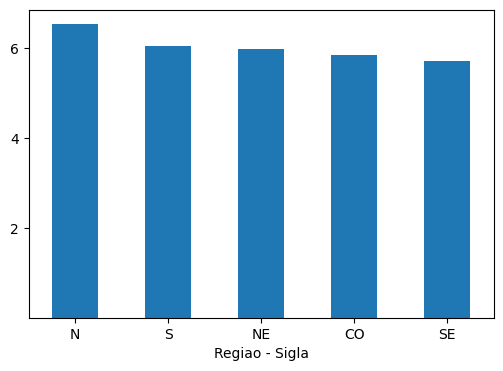

In [130]:
# Regiões
df.groupby("Regiao - Sigla")["Valor de Venda"].mean().sort_values(ascending=False).plot(kind="bar", rot=0, figsize=(6,4), yticks=[2, 4, 6])


Valores de Manaus

In [70]:
valores_manaus = df.loc[df["Municipio"] == "MANAUS"]["Valor de Venda"]

In [71]:
media_ma = round(float(valores_manaus.mean()), 2)
moda_ma = valores_manaus.mode()[0]
min_ma = valores_manaus.min()
max_ma = valores_manaus.max()
desvio_padrao_ma = valores_manaus.std()
print("\tValores de Manaus")
print(f"Media: {media_ma}\nModa: {moda_ma}")
print(f"Minimo: {min_ma}\nMaximo: {max_ma}")
print(f"Desvio padrão: {desvio_padrao_ma:.2f}")

	Valores de Manaus
Media: 6.63
Moda: 7.29
Minimo: 4.97
Maximo: 7.49
Desvio padrão: 0.72
